In [61]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

from tqdm import tqdm
from models import DeepSet, SetTransformer, CondSM
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from pathlib import Path

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [3]:
data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/dataset_wTemp/')

data_batch = np.load(data_dir / 'batch_0.npz')
print(data_batch.files)

output_idx = data_batch['out_idx'].squeeze()
radius = data_batch['radius'].squeeze()
n_a = data_batch['acc_xy'][0].shape[0]

R = np.sqrt(radius ** 2 * np.pi / 200)

print(output_idx)
print(radius)
print(n_a)
print(R)

batch_size = 1024
num_batches = 200

train_size = 0.8
val_size = 0.1
test_size = 0.1

['out_idx', 'currents', 'inputs', 'sampleStd', 'sem', 'T', 'sigma', 'min_hop_dist', 'max_hop_dist', 'a', 'nu0', 'radius', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat']
0
150.0
200
18.799712059732506


In [64]:
class TwoInputDataset(Dataset):
    def __init__(self, X, V, y):
        
        self.X = torch.as_tensor(X, dtype=torch.float32)
        self.V = torch.as_tensor(V, dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

        if self.y.dim() == 1:
            self.y = self.y.unsqueeze(1)

        assert len(self.X) == len(self.V) == len(self.y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.V[idx], self.y[idx]

voltages = []
configurations = []
currents = []
temps = []

for i in range(num_batches):

    fp = data_dir / f'batch_{i}.npz'
    try:
        batch = np.load(fp)
    except FileNotFoundError:
        continue        

    voltages.append(batch['inputs'])
    configurations.append(batch['acc_xy'])    
    temps.append(batch['T'])

    if batch['currents'].ndim != 1:
        currents.append(batch['currents'][:, output_idx])
    else:
        currents.append(batch['currents'])
        
vs = np.concatenate(voltages, axis=0)[..., [i for i in range(voltages[0].shape[1]) if i != output_idx]]
Xs = np.concatenate(configurations, axis=0) * R / radius
Ts = np.concatenate(temps, axis=0)
ys = np.concatenate(currents, axis=0)

V = torch.from_numpy(vs).float()
X = torch.from_numpy(Xs).float()
T = torch.from_numpy(Ts).unsqueeze(-1).float()
y = torch.from_numpy(ys).unsqueeze(-1).float()

print(V.shape)
print(X.shape)
print(T.shape)
print(y.shape)

dataset = TensorDataset(X, V, T, y)

generator_1 = torch.Generator().manual_seed(32)
train_ds, val_ds, test_ds = random_split(dataset, lengths=[train_size, val_size, test_size], generator=generator_1)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"train_set: {len(train_loader.dataset)}")
print(f"val_set: {len(val_loader.dataset)}")
print(f"test_set: {len(test_loader.dataset)}")

torch.Size([200000, 7])
torch.Size([200000, 200, 2])
torch.Size([200000, 1])
torch.Size([200000, 1])
train_set: 160000
val_set: 20000
test_set: 20000


In [62]:
def neg_ll(target, y):

    target = target.squeeze(-1)
    mu = y[..., 0]
    log_std = y[..., 1]
    
    N, d_out = y.shape

    sigma = F.softplus(log_std) + 1e-6
    var = sigma ** 2

    nll = 0.5 * ( 
        (target - mu) ** 2 / var 
        + 2 * torch.log(sigma) 
        + math.log(2 * math.pi) 
    )

    return nll.mean()

def sort_by_radius(x):
    r2 = (x ** 2).sum(dim=-1)
    r2_sorted, idx = torch.sort(r2, dim=1)
    pts_sorted = torch.gather(
        x, 
        dim=1,
        index=idx.unsqueeze(-1).expand(-1, -1, 2)
    )

    return pts_sorted

In [69]:
ds_h_dim = 90 # hidden dim permutation-invariant network
ds_out_dim = 4 # z_dim

num_electrodes = 7 # num of electrodes
sm_in_dim = num_electrodes + ds_out_dim + 1 # sm input dim (Ne + z_dim + T)
sm_h_dim = 90 # hidden dim sm
sm_out_dim = 2 # mu and log(sigma)
sm_layer_dims = [sm_in_dim, sm_h_dim, sm_h_dim, sm_h_dim, sm_out_dim]

num_outputs = 1
d_out = 5

deep_set = DeepSet(in_dim=2, h_dim=ds_h_dim, num_outputs=1, out_dim=ds_out_dim, aggr_type='mean')
cond_sm = CondSM(layer_dims=sm_layer_dims, dropout_p=0.1, batch_norm=True)

deep_set = deep_set.to(device)
cond_sm = cond_sm.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    list(deep_set.parameters()) + list(cond_sm.parameters()), 
    lr=1e-3
)

In [70]:
train_losses = []
val_losses = []

num_epochs = 200

with tqdm(total=num_epochs, desc="Epochs") as pbar:
    for epoch in range(1, num_epochs + 1):
    
        deep_set.train()
        cond_sm.train()
        running_loss = 0.0
        for x, v, t, y in train_loader:
            bs = x.size(0)
            #x = sort_by_radius(x)
            #x = x.view(bs, 200*2)
            x = x.to(device, non_blocking=True).float()
            v = v.to(device, non_blocking=True).float()
            t = t.to(device, non_blocking=True).float()
            y = y.to(device, non_blocking=True).float()

            #y = (y - y_mean) / y_std
            
            optimizer.zero_grad()
            
            z = deep_set(x).squeeze(dim=1)

            sm_input = torch.cat([v, t, z], dim=1).to(device)
            preds = cond_sm(sm_input)
    
            #loss = criterion(preds, y)
            loss = neg_ll(y, preds)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item() * x.size(0)
    
        epoch_train_loss = running_loss / len(train_loader.dataset)
    
        deep_set.eval()
        cond_sm.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, v, t, y in val_loader:
                bs = x.size(0)
                #x = sort_by_radius(x)
                #x = x.view(bs, 200*2)
                x = x.to(device, non_blocking=True).float()
                v = v.to(device, non_blocking=True).float()
                t = t.to(device, non_blocking=True).float()
                y = y.to(device, non_blocking=True).float()

                #y = (y - y_mean) / y_std
            
                z = deep_set(x).squeeze(dim=1)

                sm_input = torch.cat([v, t, z], dim=1).to(device)
                preds = cond_sm(sm_input)
    
                #loss  = criterion(preds, y)
                loss = neg_ll(y, preds)
                
                val_loss += loss.item() * x.size(0)
    
        epoch_val_loss = val_loss / len(val_loader.dataset)
    
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
        pbar.set_postfix({
            "epoch": f"{epoch}/{num_epochs}",
            "train": f"{epoch_train_loss:.4f}",
            "val": f"{epoch_val_loss:.4f}"
        })
        pbar.update(1)

torch.save({
    "deep_set_state_dict": deep_set.state_dict(),
    "cond_sm_state_dict": cond_sm.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses
}, f"/gpfs/bwfor/work/ws/hd_gy283-my_data/models/conditional_SM_with_temp.pth")

print(f"Model has been saved!")

Epochs:  16%|█▋        | 33/200 [01:06<05:35,  2.01s/it, epoch=33/200, train=-1.1988, val=-1.0655]Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x1516ed1cd810>>
Traceback (most recent call last):
  File "/home/hd/hd_hd/hd_gy283/.conda/envs/py311/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
Epochs:  16%|█▋        | 33/200 [01:07<05:41,  2.05s/it, epoch=33/200, train=-1.1988, val=-1.0655]


KeyboardInterrupt: 

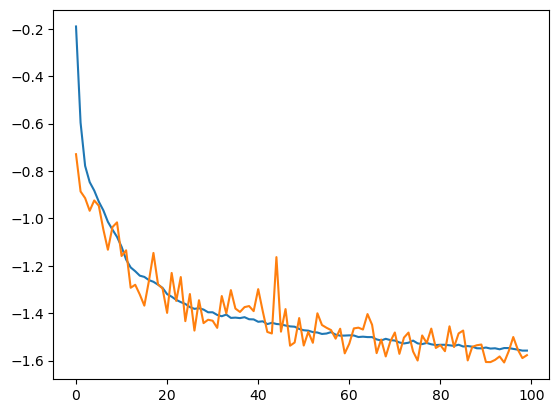

In [71]:
model_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/models/conditional_SM_with_temp.pth')

deep_set = DeepSet(in_dim=2, h_dim=ds_h_dim, num_outputs=1, out_dim=ds_out_dim, aggr_type='mean')
cond_sm = CondSM(layer_dims=sm_layer_dims, dropout_p=0.1, batch_norm=True)

deep_set.load_state_dict(model_dict['deep_set_state_dict'])
cond_sm.load_state_dict(model_dict['cond_sm_state_dict'])

deep_set = deep_set.to(device)
cond_sm = cond_sm.to(device)

plt.plot(model_dict['train_losses'])
plt.plot(model_dict['val_losses'])

-0.80884445 0.77755606


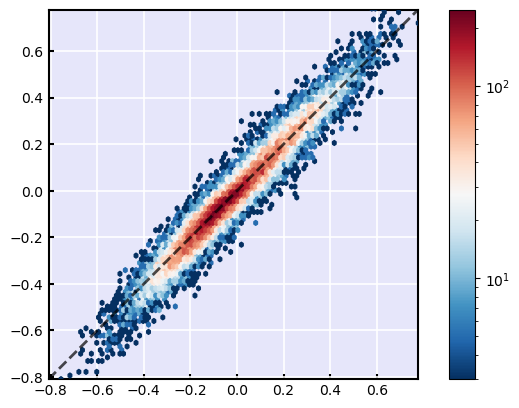

In [79]:
deep_set.eval()
cond_sm.eval()

pred_params = []
y_true_l = []
latent_l = []
with torch.no_grad():
    for x, v, t, y in test_loader:
        bs = x.size(0)
        x = x.to(device, non_blocking=True).float()
        v = v.to(device, non_blocking=True).float()
        t = t.to(device, non_blocking=True).float()
        y = y.to(device, non_blocking=True).float()

        z = deep_set(x).squeeze()
        
        sm_input = torch.cat([v, t, z], dim=1)
        preds = cond_sm(sm_input).detach().cpu().numpy()
        pred_params.append(preds)
        y_true_l.append(y.cpu().numpy())
        latent_l.append(z.detach().cpu().numpy())

y_pred_l = [params[..., 0] for params in pred_params]

from utils import pred_vs_true
from matplotlib.colors import LogNorm

y_pred = np.concatenate(y_pred_l, axis=0).ravel()
y_true = np.concatenate(y_true_l, axis=0).ravel()

lo = min(y_pred.min(), y_true.min())
hi = min(y_pred.max(), y_true.max())
print(lo, hi)
plot_range = [[lo, hi], [lo, hi]]

fig, ax = plt.subplots()

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)

norm = LogNorm()

im = ax.hexbin(y_pred, y_true, bins=250, gridsize=100, norm=norm, cmap="RdBu_r", zorder=5)
#_, _, _, im = ax.hist2d(y_pred, y_true, bins=200, range=plot_range, norm=norm, cmap="RdBu", zorder=5)
ax.plot([lo, hi], [lo, hi], linestyle='--', linewidth=2, color='k', alpha=0.7, zorder=6)

fig = ax.figure
cax = fig.add_axes([ax.get_position().x1 - 0.05, ax.get_position().y0, 0.04, ax.get_position().height])
plt.colorbar(im, cax=cax)

ax.spines[:].set_linewidth(1.5)
ax.spines[:].set_facecolor('w')
ax.tick_params(direction='in', width=1.5)
ax.set_facecolor('lavender')
ax.grid(c='w', lw=1.2)

ax.set_aspect('equal', adjustable='box')